<a href="https://colab.research.google.com/github/yalindi/2425568_ml/blob/main/2425568.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/yalindi/2425568_ml.git

fatal: destination path '2425568_ml' already exists and is not an empty directory.


#Mount the Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##**Import libraries**


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# we want our plot to appear inside the notebook
%matplotlib inline

# models from scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# model evaluation
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import precision_score,recall_score,f1_score
from sklearn.metrics import RocCurveDisplay

# **Preprocessing** **Data**

In [4]:
df = pd.read_csv('/content/2425568_ml/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
#Drop missing TotalCharges
df_copy=df
df_copy['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median())

In [8]:
df_copy.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df_copy=df.drop("customerID",axis=1)

In [11]:
df_copy.head().T

,0,1,2,3,4
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No
OnlineBackup,Yes,No,Yes,No,No


In [12]:
#Covert Yes/No columns to 1/0
for col in df_copy.columns:
  if set(df_copy[col].unique())==set(['Yes','No']):
    df_copy[col]=df_copy[col].map({'Yes':1,'No':0})

In [13]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


In [14]:
#Convert Gender Column Male=1 Female=0
if 'gender' in df_copy.columns:
  df_copy['gender']=df_copy['gender'].map({'Male':1,'Female':0})

df_copy['gender'].dtypes

dtype('int64')

In [15]:
X=df_copy.drop('Churn',axis=1)
y=df_copy['Churn']

In [16]:
for col in df_copy.columns:
  if (df_copy[col].dtypes)=='object':
    print(col)

MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaymentMethod


In [17]:
#Split the data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [18]:
#One-hot encoder
categorical_features=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod']
one_hot=OneHotEncoder()
transformer=ColumnTransformer([("one_hot",
                               one_hot,
                               categorical_features)],
                              remainder="passthrough")
X_train=transformer.fit_transform(X_train)
X_test=transformer.transform(X_test)

# **DecisionTreeClassifier**

In [19]:
#fit the model
model_1=DecisionTreeClassifier(random_state=42,class_weight="balanced")
model_1.fit(X_train,y_train)


DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [20]:
model_1.score(X_test,y_test)

0.7311878845243729

### Hyperparameter Tuning with RandomizedSearchCV


In [21]:
rs_grid={
    "criterion":["gini", "entropy", "log_loss"],
    "max_depth":np.arange(1,10),
    "min_samples_split":np.arange(2,10),
    "min_samples_leaf":[1,2,4,5,7,8,10]

}
np.random.seed(42)

rs=RandomizedSearchCV(model_1,
                      param_distributions=rs_grid,
                      cv=5,
                      n_iter=30,
                      verbose=True)

rs.fit(X_train,y_train)
rs.best_params_

Fitting 5 folds for each of 30 candidates, totalling 150 fits


{'min_samples_split': np.int64(7),
 'min_samples_leaf': 4,
 'max_depth': np.int64(5),
 'criterion': 'log_loss'}

In [22]:
rs.score(X_test,y_test)

0.7586370089919545

### Hyperparameter Tuning with gridSearchCV

In [23]:
gs_grid={
    "criterion":["entropy", "log_loss"],
    "max_depth":[5],
    "min_samples_split":[5,6,7,9],
    "min_samples_leaf":[3,4,6,8]
}

np.random.seed(42)

gs=GridSearchCV(model_1,
                param_grid=gs_grid,
                cv=5,
                verbose=True)

gs.fit(X_train,y_train)
gs.best_params_

Fitting 5 folds for each of 32 candidates, totalling 160 fits


{'criterion': 'entropy',
 'max_depth': 5,
 'min_samples_leaf': 4,
 'min_samples_split': 5}

In [24]:
gs.score(X_test,y_test)

0.7586370089919545

### evaluate model_1

In [25]:
y_preds=gs.predict(X_test)

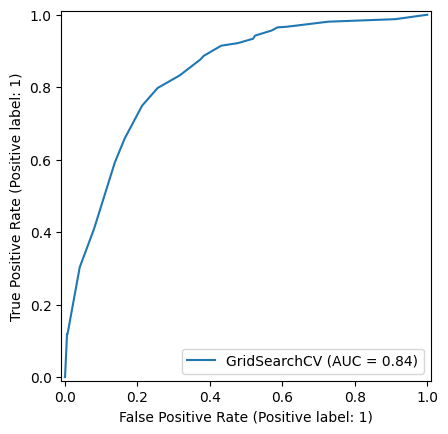

In [26]:
RocCurveDisplay.from_estimator(gs,
                               X_test,
                               y_test)

In [27]:
confusion_matrix(y_test, y_preds)

array([[1145,  394],
       [ 116,  458]])

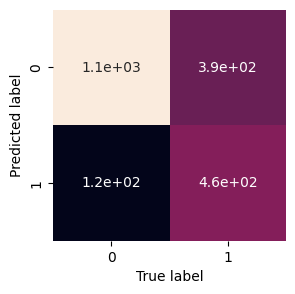

In [28]:
def plot_conf_mat(y_test, y_preds):
    """
    Plots a nice looking confusion matrix using Seaborn's heatmap()
    """
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True,
                     cbar=False)
    plt.xlabel("True label")
    plt.ylabel("Predicted label")

    bottom, top = ax.get_ylim()
    #ax.set_ylim(bottom + 0.5, top - 0.5)
    plt.show()

plot_conf_mat(y_test, y_preds)

In [29]:
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1539
           1       0.54      0.80      0.64       574

    accuracy                           0.76      2113
   macro avg       0.72      0.77      0.73      2113
weighted avg       0.81      0.76      0.77      2113



In [30]:
# cross-validated accuracy
X_encoded = transformer.transform(X)
cv_acc = cross_val_score(gs,
                         X_encoded,
                         y,
                         cv=5,
                         scoring="accuracy")
cv_acc=np.mean(cv_acc)

# cross-validated precision
cv_precision = cross_val_score(gs,
                         X_encoded,
                         y,
                         cv=5,
                         scoring="precision")
cv_precision=np.mean(cv_precision)

# cross-validated recall
cv_recall = cross_val_score(gs,
                         X_encoded,
                         y,
                         cv=5,
                         scoring="recall")
cv_recall = np.mean(cv_recall)

# cross-validated f1
cv_f1 = cross_val_score(gs,
                         X_encoded,
                         y,
                         cv=5,
                         scoring="f1")
cv_f1 = np.mean(cv_f1)

print("cross-validated accuracy :",cv_acc)
print("cross-validated precision: ",cv_precision)
print("cross-validated recall: ",cv_recall)
print("cross-validated f1: ",cv_f1)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Fitting 

#**Neural Network**

In [31]:
import tensorflow as tf